# FORGE Analytics — Revenue Forecast
### Notebook 1 of 3 · FP&A Portfolio · Antonio Heredia

This notebook analyzes historical revenue data for FORGE, a fictional B2B SaaS company, 
and builds a simple revenue forecast for the next 6 months.

**What this notebook covers:**
- Loading and exploring revenue data from the FORGE database
- Monthly revenue trend analysis by segment
- 6-month revenue forecast using linear trend
- Visualization of historical vs forecasted revenue


In [1]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Connect to FORGE database
conn = sqlite3.connect('../data/forge.db')

# Load revenue transactions
df = pd.read_sql_query("""
    SELECT 
        month,
        segment,
        SUM(revenue) as revenue
    FROM revenue_transactions
    GROUP BY month, segment
    ORDER BY month ASC
""", conn)

# Convert month to datetime
df['month'] = pd.to_datetime(df['month'])

print("Data loaded successfully")
print(f"Date range: {df['month'].min().strftime('%b %Y')} to {df['month'].max().strftime('%b %Y')}")
print(f"Total rows: {len(df)}")
print()
print(df.head(10))


Data loaded successfully
Date range: Jan 2024 to Mar 2026
Total rows: 79

       month     segment    revenue
0 2024-01-01  Mid-Market    1256.24
1 2024-02-01  Enterprise   49363.67
2 2024-02-01  Mid-Market   21447.26
3 2024-02-01         SMB    7138.15
4 2024-03-01  Enterprise   70672.42
5 2024-03-01  Mid-Market   37426.86
6 2024-03-01         SMB   12727.64
7 2024-04-01  Enterprise  110261.58
8 2024-04-01  Mid-Market   59431.76
9 2024-04-01         SMB   19128.14


## Step 1 — Monthly revenue trend

First we look at total revenue by month across all segments to understand 
the growth trajectory of FORGE before building the forecast.

In [2]:
# Total revenue by month
monthly = df.groupby('month')['revenue'].sum().reset_index()
monthly.columns = ['month', 'total_revenue']

print("Monthly revenue summary:")
print(monthly.to_string())


Monthly revenue summary:
        month  total_revenue
0  2024-01-01        1256.24
1  2024-02-01       77949.08
2  2024-03-01      120826.92
3  2024-04-01      188821.48
4  2024-05-01      245516.74
5  2024-06-01      315313.20
6  2024-07-01      389022.98
7  2024-08-01      447692.55
8  2024-09-01      548679.11
9  2024-10-01      629481.62
10 2024-11-01      742948.09
11 2024-12-01      818495.51
12 2025-01-01      882827.55
13 2025-02-01      989865.18
14 2025-03-01     1023546.07
15 2025-04-01     1100643.59
16 2025-05-01     1211092.94
17 2025-06-01     1341562.97
18 2025-07-01     1423388.54
19 2025-08-01     1477634.40
20 2025-09-01     1535175.62
21 2025-10-01     1531376.44
22 2025-11-01     1552791.41
23 2025-12-01     1544021.83
24 2026-01-01     1533038.04
25 2026-02-01     1517785.49
26 2026-03-01     1527997.44


## Step 2 — Revenue visualization

Plotting the monthly revenue trend to visualize FORGE's growth trajectory.

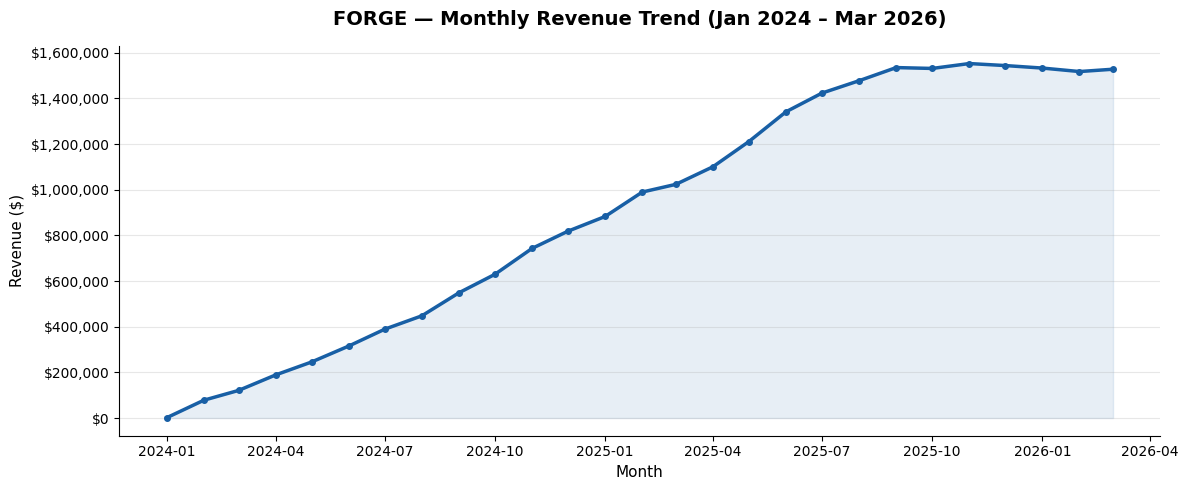

Chart saved.


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly['month'], monthly['total_revenue'], 
        color='#185FA5', linewidth=2.5, marker='o', markersize=4)

ax.fill_between(monthly['month'], monthly['total_revenue'], 
                alpha=0.1, color='#185FA5')

ax.set_title('FORGE — Monthly Revenue Trend (Jan 2024 – Mar 2026)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Step 3 — Revenue forecast (next 6 months)

Using the last 6 months of data to fit a linear trend and project 
revenue for April 2026 through September 2026.

In [4]:
from datetime import timedelta

# Use last 6 months as basis for forecast
last_6 = monthly.tail(6).copy()
last_6['month_num'] = range(len(last_6))

# Fit linear trend
coeffs = np.polyfit(last_6['month_num'], last_6['total_revenue'], 1)
slope = coeffs[0]
intercept = coeffs[1]

print(f"Trend slope: ${slope:,.0f} per month")
print(f"Last actual revenue: ${monthly['total_revenue'].iloc[-1]:,.0f}")

# Generate 6 forecast months
last_month = monthly['month'].iloc[-1]
forecast_months = [last_month + pd.DateOffset(months=i+1) for i in range(6)]
last_num = last_6['month_num'].iloc[-1]
forecast_values = [intercept + slope * (last_num + i + 1) for i in range(6)]

forecast_df = pd.DataFrame({
    'month': forecast_months,
    'forecast_revenue': [round(v, 2) for v in forecast_values]
})

print("\n6-Month Revenue Forecast:")
print(forecast_df.to_string())

Trend slope: $-3,797 per month
Last actual revenue: $1,527,997

6-Month Revenue Forecast:
       month  forecast_revenue
0 2026-04-01        1521212.12
1 2026-05-01        1517415.08
2 2026-06-01        1513618.03
3 2026-07-01        1509820.99
4 2026-08-01        1506023.94
5 2026-09-01        1502226.90


## Step 4 — Forecast visualization

Plotting historical revenue alongside the 6-month forward forecast.

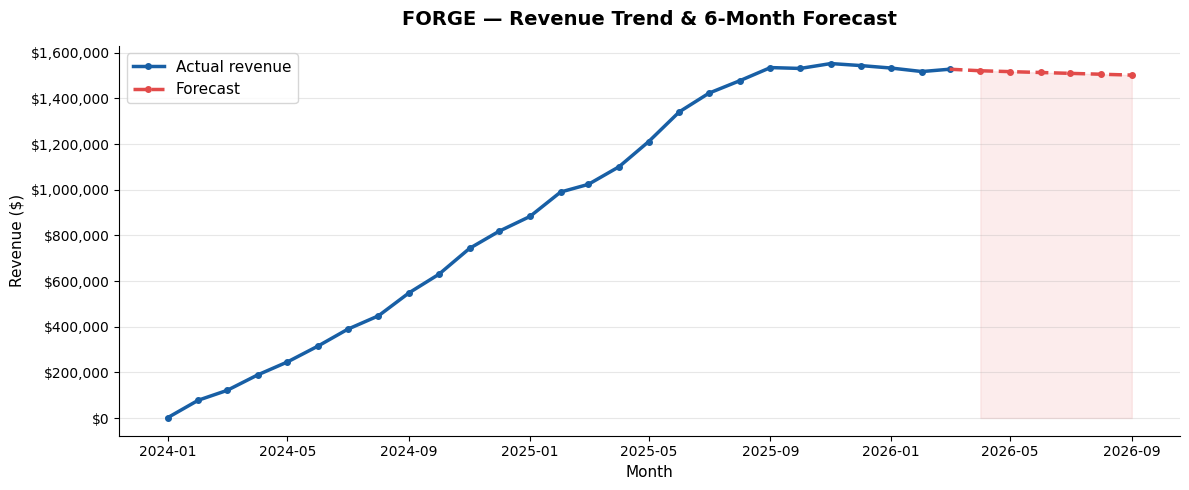

Forecast chart saved.


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

# Historical
ax.plot(monthly['month'], monthly['total_revenue'],
        color='#185FA5', linewidth=2.5, 
        marker='o', markersize=4, label='Actual revenue')

# Forecast
ax.plot(forecast_df['month'], forecast_df['forecast_revenue'],
        color='#E24B4A', linewidth=2.5, linestyle='--',
        marker='o', markersize=4, label='Forecast')

# Connect last actual to first forecast
ax.plot([monthly['month'].iloc[-1], forecast_df['month'].iloc[0]],
        [monthly['total_revenue'].iloc[-1], forecast_df['forecast_revenue'].iloc[0]],
        color='#E24B4A', linewidth=2.5, linestyle='--')

# Shade forecast area
ax.fill_between(forecast_df['month'], forecast_df['forecast_revenue'],
                alpha=0.1, color='#E24B4A')

ax.set_title('FORGE — Revenue Trend & 6-Month Forecast', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Forecast chart saved.")

## Key findings & FP&A implications

**Revenue trajectory:**
- FORGE grew from ~$1,200 MRR in Jan 2024 to $1.53M MRR by Mar 2026
- Growth rate peaked in mid-2024 and has been decelerating since Q3 2025
- Revenue has plateaued at ~$1.5M/month for the last 6 months

**Forecast outlook (Apr–Sep 2026):**
- Linear trend projects a gradual decline of ~$3,800/month
- Projected Sep 2026 revenue: $1,502,227 (-1.7% vs Mar 2026)
- This signals churn is slightly outpacing new customer acquisition

**Management implications:**
1. New customer acquisition needs to accelerate to reverse the trend
2. Focus retention efforts on SMB segment — highest churn rate at 6%/month
3. Enterprise expansion revenue is the highest-leverage growth lever